# Mutual Fund Analytics — Exploratory Data Analysis
**Project:** Bluestock Mutual Fund Analytics | **Day 3:** EDA & Visualisation


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings, os

warnings.filterwarnings('ignore')

# All paths relative to project root (notebook is in notebooks/)
PROC = '../data/processed'
REP  = '../reports'
os.makedirs(REP, exist_ok=True)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('Libraries loaded')
print(f'Reading from : {os.path.abspath(PROC)}')
print(f'Saving to    : {os.path.abspath(REP)}')

Libraries loaded
Reading from : c:\Users\Jatin\Desktop\Bluestocks\Mutual-Funds-Analytics\data\processed
Saving to    : c:\Users\Jatin\Desktop\Bluestocks\Mutual-Funds-Analytics\reports


## Load All Cleaned Datasets

In [9]:
fm   = pd.read_csv(f'{PROC}/01_fund_master.csv')
nav  = pd.read_csv(f'{PROC}/02_nav_history.csv',  parse_dates=['date'])
aum  = pd.read_csv(f'{PROC}/03_aum_by_fund_house.csv', parse_dates=['date'])
sip  = pd.read_csv(f'{PROC}/04_monthly_sip_inflows.csv')
cat  = pd.read_csv(f'{PROC}/05_category_inflows.csv')
fol  = pd.read_csv(f'{PROC}/06_industry_folio_count.csv')
perf = pd.read_csv(f'{PROC}/07_scheme_performance.csv')
txn  = pd.read_csv(f'{PROC}/08_investor_transactions.csv', parse_dates=['transaction_date'])
ph   = pd.read_csv(f'{PROC}/09_portfolio_holdings.csv')
bi   = pd.read_csv(f'{PROC}/10_benchmark_indices.csv', parse_dates=['date'])

# Parse month columns - use errors='coerce' to handle any format
sip['month_dt'] = pd.to_datetime(sip['month'], infer_datetime_format=True, errors='coerce')
cat['month_dt'] = pd.to_datetime(cat['month'], infer_datetime_format=True, errors='coerce')
fol['month_dt'] = pd.to_datetime(fol['month'], infer_datetime_format=True, errors='coerce')

# Merge nav with fund names
nav = nav.merge(fm[['amfi_code','scheme_name','fund_house','sub_category','plan']], on='amfi_code', how='left')

print('All datasets loaded')
print(f'  NAV rows     : {len(nav):,}')
print(f'  Transactions : {len(txn):,}')
print(f'  Schemes      : {fm["amfi_code"].nunique()}')
print(f'  Date range   : {nav["date"].min().date()} to {nav["date"].max().date()}')

All datasets loaded
  NAV rows     : 64,320
  Transactions : 32,778
  Schemes      : 40
  Date range   : 2022-01-03 to 2026-05-29


## Chart 1 — NAV Trend Analysis (2022–2026)
Daily NAV for selected schemes with bull run and correction highlighted.

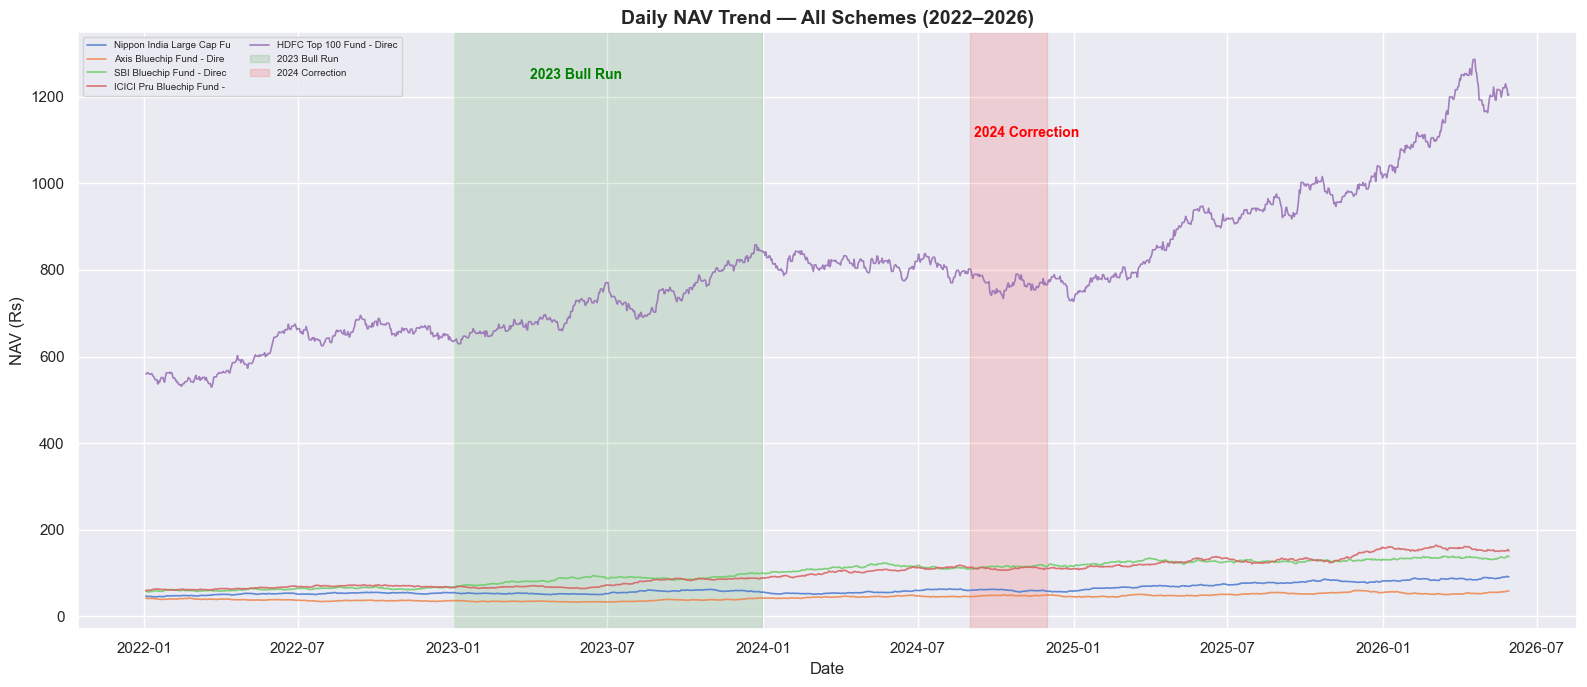

Chart 1 saved


In [10]:
selected = fm[fm['plan']=='Direct'].groupby('fund_house').first().reset_index()['amfi_code'].tolist()
nav_sel  = nav[nav['amfi_code'].isin(selected)].copy()

fig, ax = plt.subplots(figsize=(16, 7))

for code_id, grp in nav_sel.groupby('amfi_code'):
    name = grp['scheme_name'].iloc[0][:25]
    ax.plot(grp['date'], grp['nav'], linewidth=1.2, label=name, alpha=0.85)

# 2023 Bull Run
ax.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2023-12-31'),
           alpha=0.12, color='green', label='2023 Bull Run')
ax.text(pd.Timestamp('2023-04-01'), ax.get_ylim()[1]*0.92,
        '2023 Bull Run', color='green', fontsize=10, fontweight='bold')

# 2024 Correction
ax.axvspan(pd.Timestamp('2024-09-01'), pd.Timestamp('2024-11-30'),
           alpha=0.12, color='red', label='2024 Correction')
ax.text(pd.Timestamp('2024-09-05'), ax.get_ylim()[1]*0.82,
        '2024 Correction', color='red', fontsize=10, fontweight='bold')

ax.set_title('Daily NAV Trend — All Schemes (2022–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('NAV (Rs)')
ax.legend(fontsize=7, loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig(f'{REP}/chart_01_nav_trend.png', dpi=150, bbox_inches='tight')
# plt.savefig(REP / "chart_01_nav_trend.png", dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved')

## Chart 2 — AUM Growth by Fund House (2022–2025)

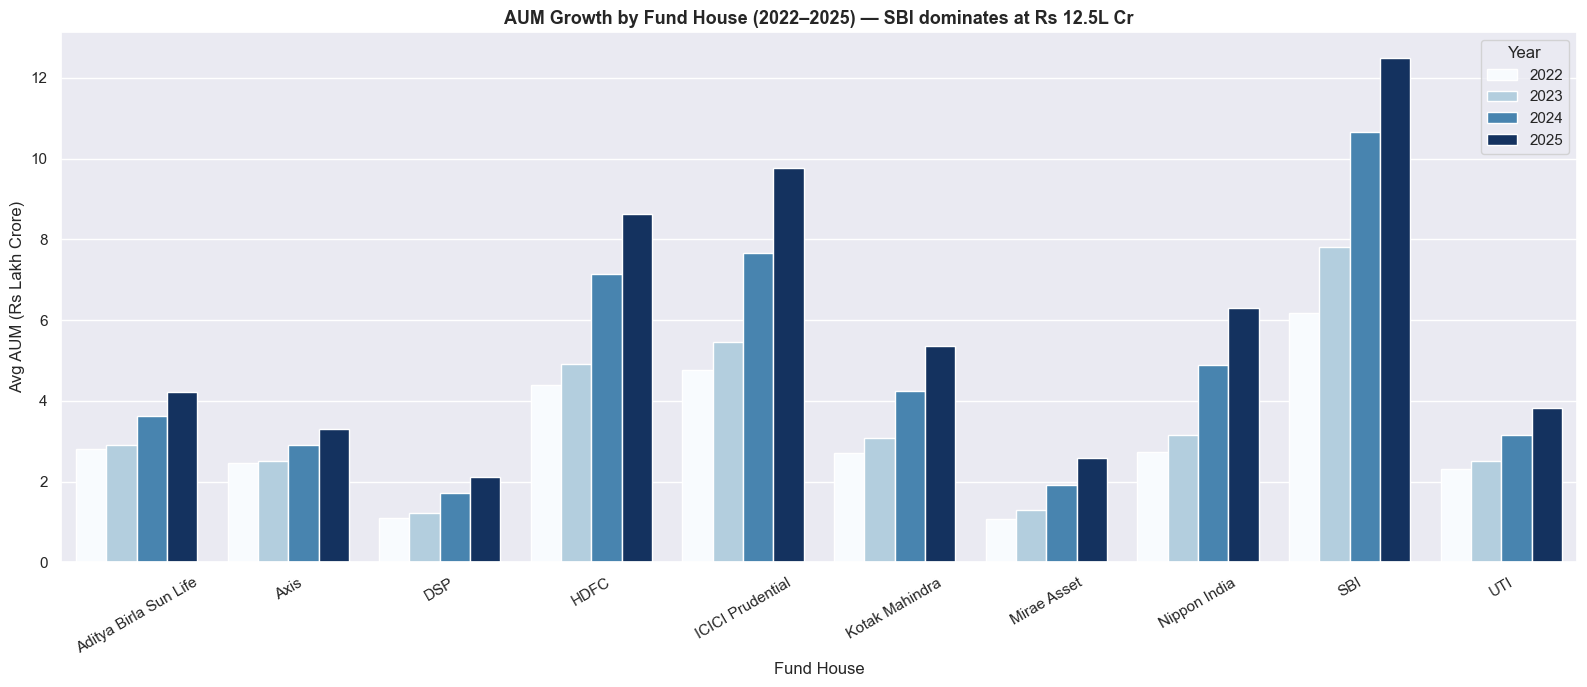

Chart 2 saved


In [11]:
aum['year'] = aum['date'].dt.year
aum_yr = aum.groupby(['fund_house','year'])['aum_lakh_crore'].mean().reset_index()
aum_yr = aum_yr[aum_yr['year'].between(2022, 2025)]
aum_yr['fh_short'] = aum_yr['fund_house'].str.replace(' Mutual Fund','',regex=False)                                          .str.replace(' MF','',regex=False)                                          .str.replace(' Asset MF','',regex=False)

fig, ax = plt.subplots(figsize=(16, 7))
sns.barplot(data=aum_yr, x='fh_short', y='aum_lakh_crore', hue='year', palette='Blues', ax=ax)

ax.set_title('AUM Growth by Fund House (2022–2025) — SBI dominates at Rs 12.5L Cr',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Fund House')
ax.set_ylabel('Avg AUM (Rs Lakh Crore)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Year', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{REP}/chart_02_aum_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved')

## Chart 3 — SIP Inflow Time Series (Jan 2022 – Dec 2025)

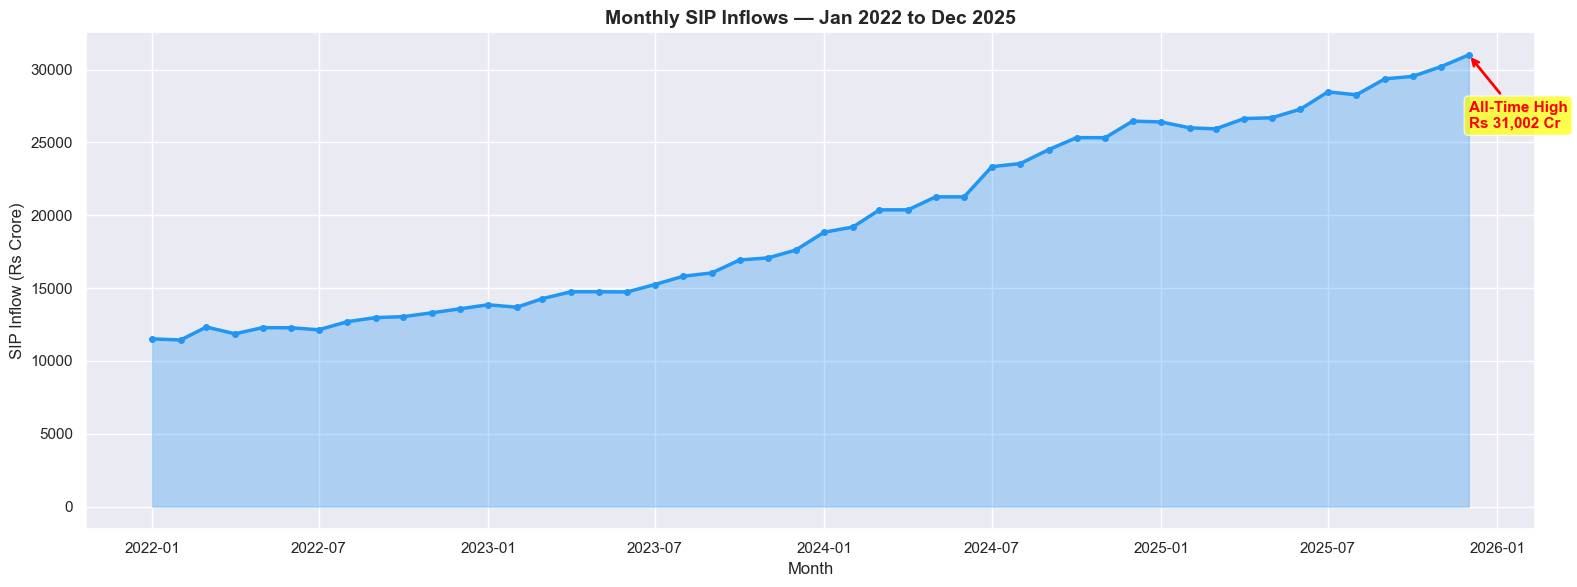

Chart 3 saved


In [12]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.fill_between(sip['month_dt'], sip['sip_inflow_crore'],
                alpha=0.3, color='#2196F3')
ax.plot(sip['month_dt'], sip['sip_inflow_crore'],
        color='#2196F3', linewidth=2.5, marker='o', markersize=4)

# All-time high annotation
ath_idx = sip['sip_inflow_crore'].idxmax()
ath_x   = sip.loc[ath_idx, 'month_dt']
ath_y   = sip.loc[ath_idx, 'sip_inflow_crore']
ax.annotate(f'All-Time High\nRs {ath_y:,.0f} Cr',
            xy=(ath_x, ath_y), xytext=(ath_x, ath_y - 5000),
            fontsize=11, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.7))

ax.set_title('Monthly SIP Inflows — Jan 2022 to Dec 2025', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('SIP Inflow (Rs Crore)')
plt.tight_layout()
plt.savefig(f'{REP}/chart_03_sip_inflow.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved')

## Chart 4 — Category Inflow Heatmap

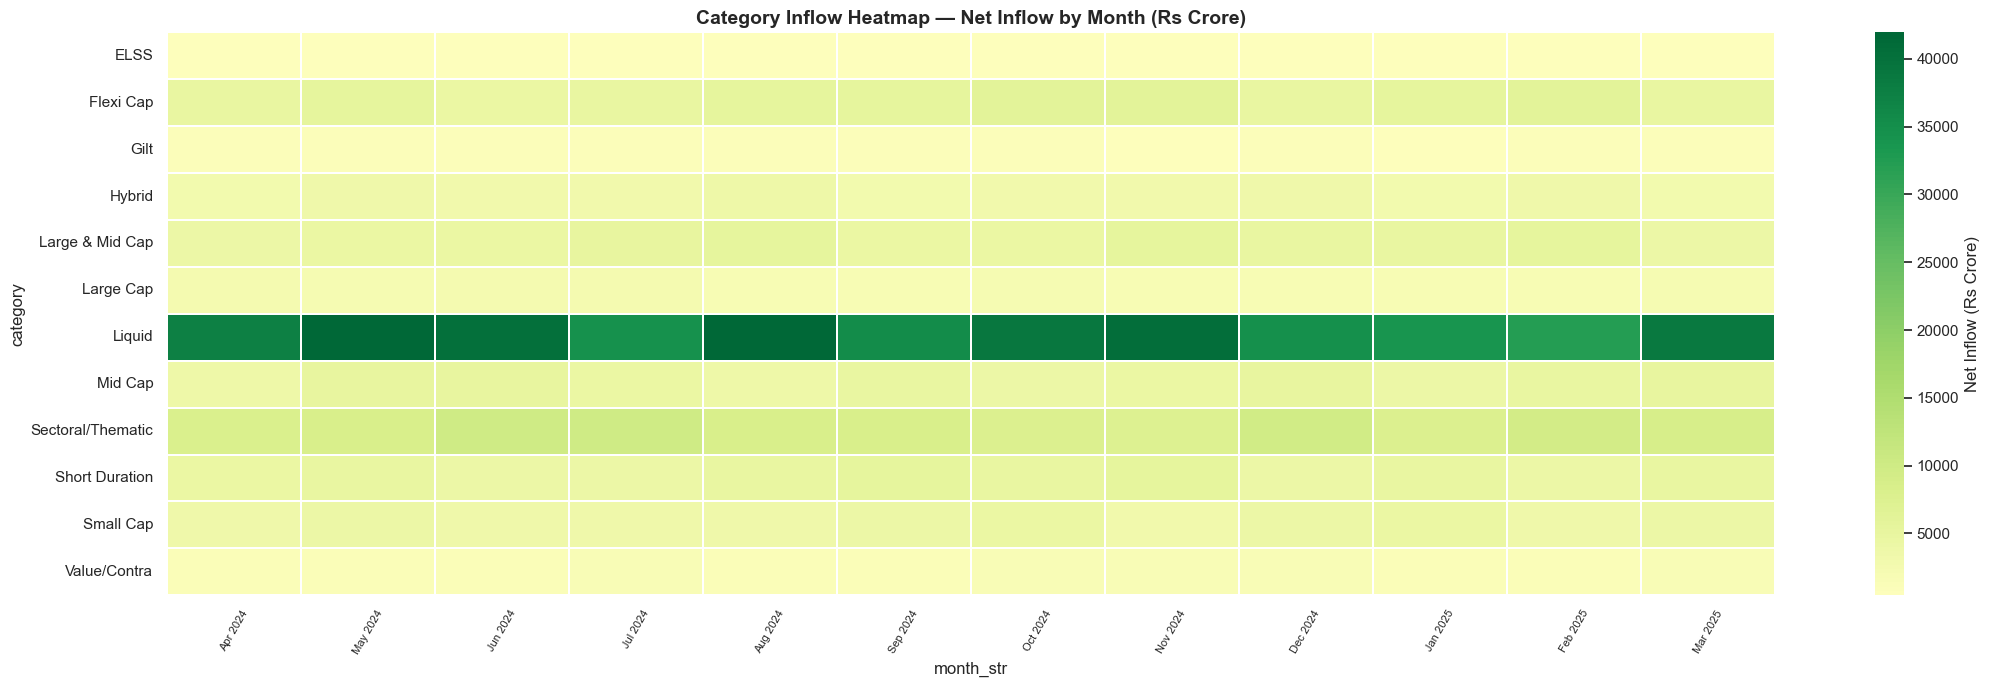

Chart 4 saved


In [13]:
cat['month_str'] = cat['month_dt'].dt.strftime('%b %Y')
pivot = cat.pivot_table(index='category', columns='month_str',
                        values='net_inflow_crore', aggfunc='sum')

col_order = sorted(cat['month_dt'].unique())
col_order = [pd.Timestamp(m).strftime('%b %Y') for m in col_order]
col_order = [c for c in col_order if c in pivot.columns]
pivot = pivot[col_order]

fig, ax = plt.subplots(figsize=(22, 7))
sns.heatmap(pivot, cmap='RdYlGn', center=0, linewidths=0.3,
            annot=False, ax=ax,
            cbar_kws={'label': 'Net Inflow (Rs Crore)'})
ax.set_title('Category Inflow Heatmap — Net Inflow by Month (Rs Crore)',
             fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=60, labelsize=8)
plt.tight_layout()
plt.savefig(f'{REP}/chart_04_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved')

## Chart 5 — Investor Demographics (Age, SIP Amount, Gender)

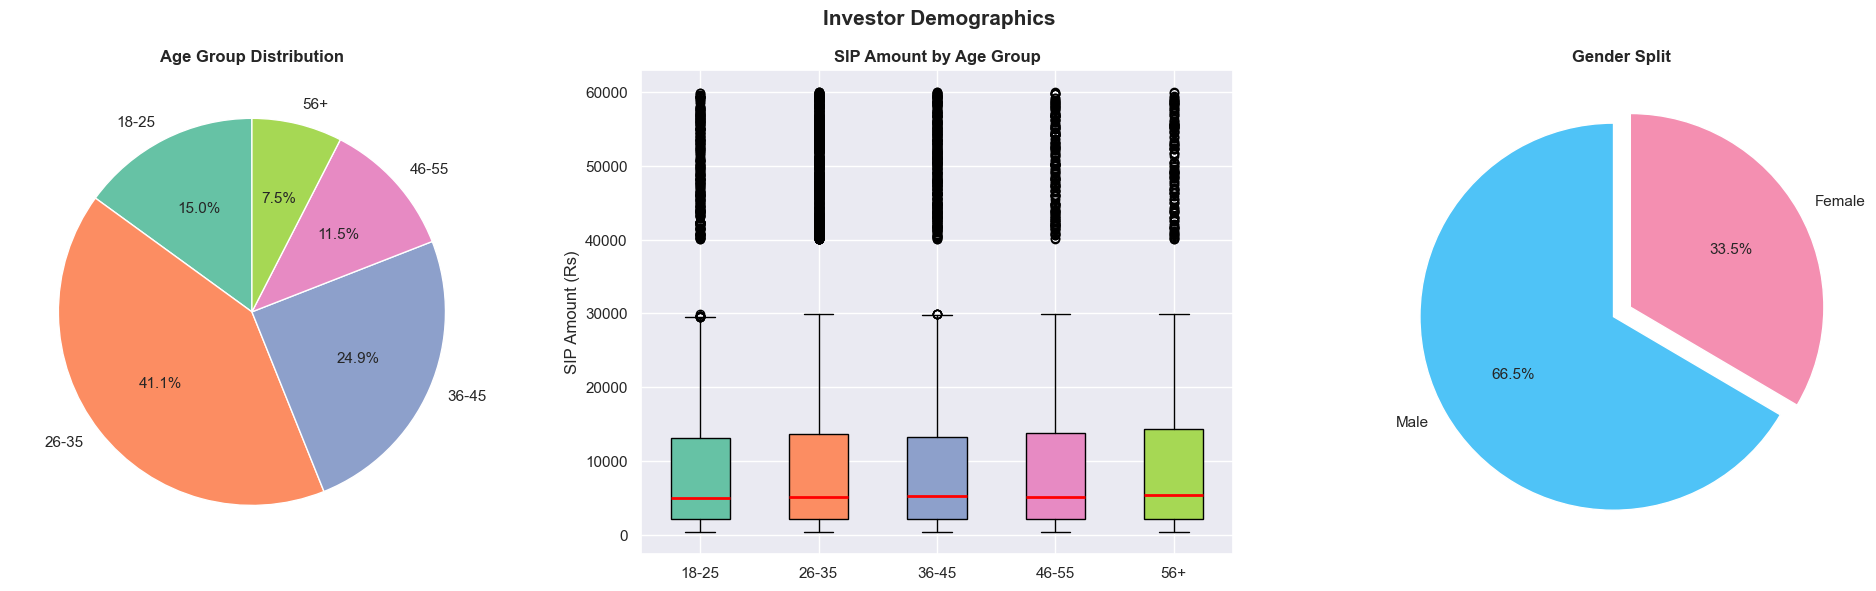

Chart 5 saved


In [14]:
sip_txn   = txn[txn['transaction_type'] == 'SIP'].copy()
age_order = ['18-25', '26-35', '36-45', '46-55', '56+']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 5a Age pie
age_counts = txn['age_group'].value_counts().reindex(age_order)
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(age_counts)), startangle=90)
axes[0].set_title('Age Group Distribution', fontweight='bold')

# 5b SIP box plot
sip_by_age = [sip_txn[sip_txn['age_group']==ag]['amount_inr'].values for ag in age_order]
bp = axes[1].boxplot(sip_by_age, labels=age_order, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], sns.color_palette('Set2', len(age_order))):
    patch.set_facecolor(color)
axes[1].set_title('SIP Amount by Age Group', fontweight='bold')
axes[1].set_ylabel('SIP Amount (Rs)')

# 5c Gender pie
gen_counts = txn['gender'].value_counts()
axes[2].pie(gen_counts, labels=gen_counts.index, autopct='%1.1f%%',
            colors=['#4FC3F7', '#F48FB1'], startangle=90, explode=[0.05]*len(gen_counts))
axes[2].set_title('Gender Split', fontweight='bold')

plt.suptitle('Investor Demographics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REP}/chart_05_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5 saved')

## Chart 6 — Geographic Distribution

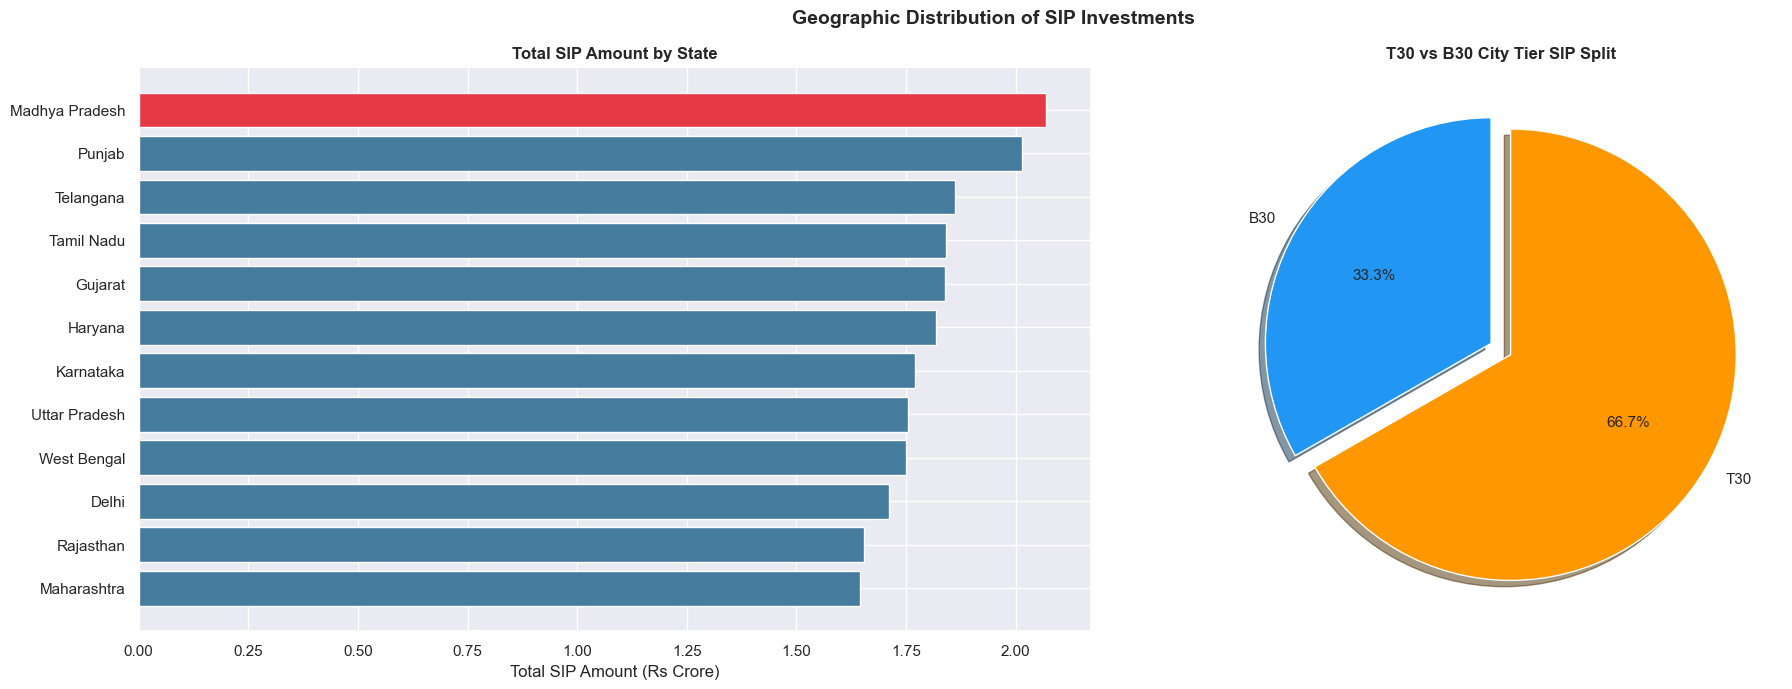

Chart 6 saved


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# State bar
state_sip = txn[txn['transaction_type']=='SIP']    .groupby('state')['amount_inr'].sum().sort_values(ascending=True)
colors_bar = ['#E63946' if v == state_sip.max() else '#457B9D' for v in state_sip.values]
axes[0].barh(state_sip.index, state_sip.values / 1e7, color=colors_bar)
axes[0].set_title('Total SIP Amount by State', fontweight='bold')
axes[0].set_xlabel('Total SIP Amount (Rs Crore)')

# T30 vs B30 pie
tier_sip = txn[txn['transaction_type']=='SIP']    .groupby('city_tier')['amount_inr'].sum()
axes[1].pie(tier_sip, labels=tier_sip.index, autopct='%1.1f%%',
            colors=['#2196F3', '#FF9800'], startangle=90,
            explode=[0.05, 0.05], shadow=True)
axes[1].set_title('T30 vs B30 City Tier SIP Split', fontweight='bold')

plt.suptitle('Geographic Distribution of SIP Investments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REP}/chart_06_geography.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 6 saved')

## Chart 7 — Folio Count Growth (2022–2025)

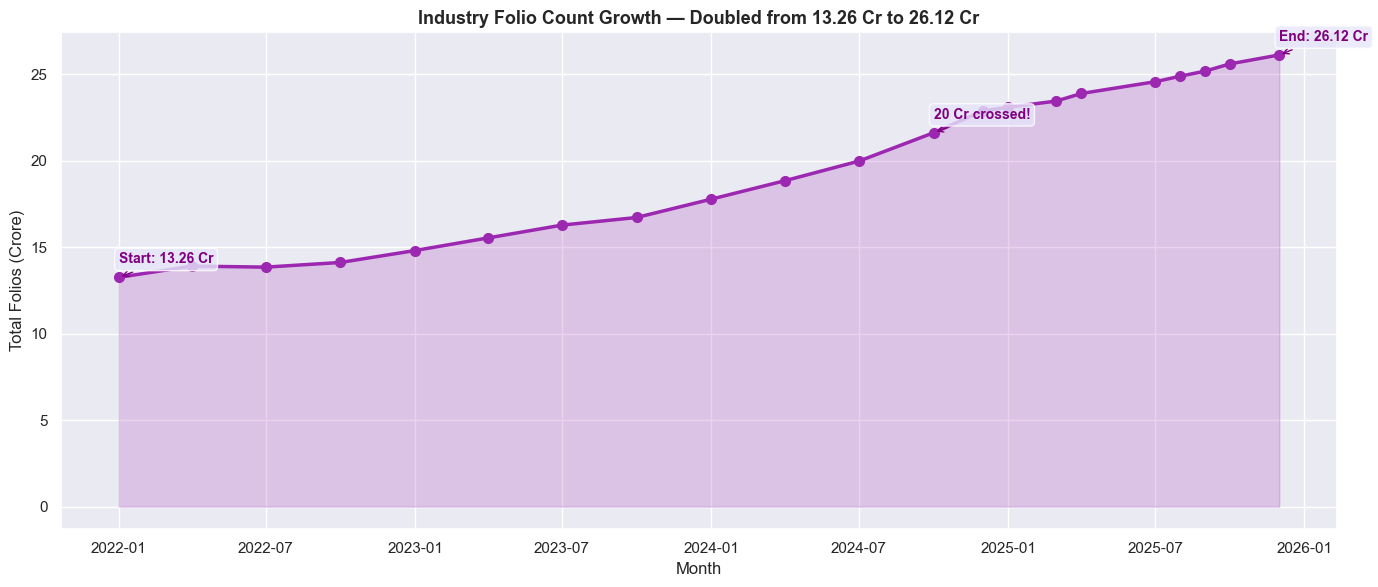

Chart 7 saved


In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(fol['month_dt'], fol['total_folios_crore'],
                alpha=0.2, color='#9C27B0')
ax.plot(fol['month_dt'], fol['total_folios_crore'],
        color='#9C27B0', linewidth=2.5, marker='o', markersize=7)

# Milestones
milestones = [
    (fol.iloc[0]['month_dt'],  fol.iloc[0]['total_folios_crore'],  'Start: 13.26 Cr'),
    (fol.iloc[-1]['month_dt'], fol.iloc[-1]['total_folios_crore'], 'End: 26.12 Cr'),
]
cross20 = fol[fol['total_folios_crore'] >= 20].head(1)
if not cross20.empty:
    milestones.append((cross20.iloc[0]['month_dt'],
                       cross20.iloc[0]['total_folios_crore'], '20 Cr crossed!'))

for mx, my, mtxt in milestones:
    ax.annotate(mtxt, xy=(mx, my), xytext=(mx, my + 0.8),
                fontsize=10, fontweight='bold', color='purple',
                arrowprops=dict(arrowstyle='->', color='purple'),
                bbox=dict(boxstyle='round', fc='lavender', alpha=0.8))

ax.set_title('Industry Folio Count Growth — Doubled from 13.26 Cr to 26.12 Cr',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Folios (Crore)')
plt.tight_layout()
plt.savefig(f'{REP}/chart_07_folio_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 7 saved')

## Chart 8 — NAV Return Correlation Matrix

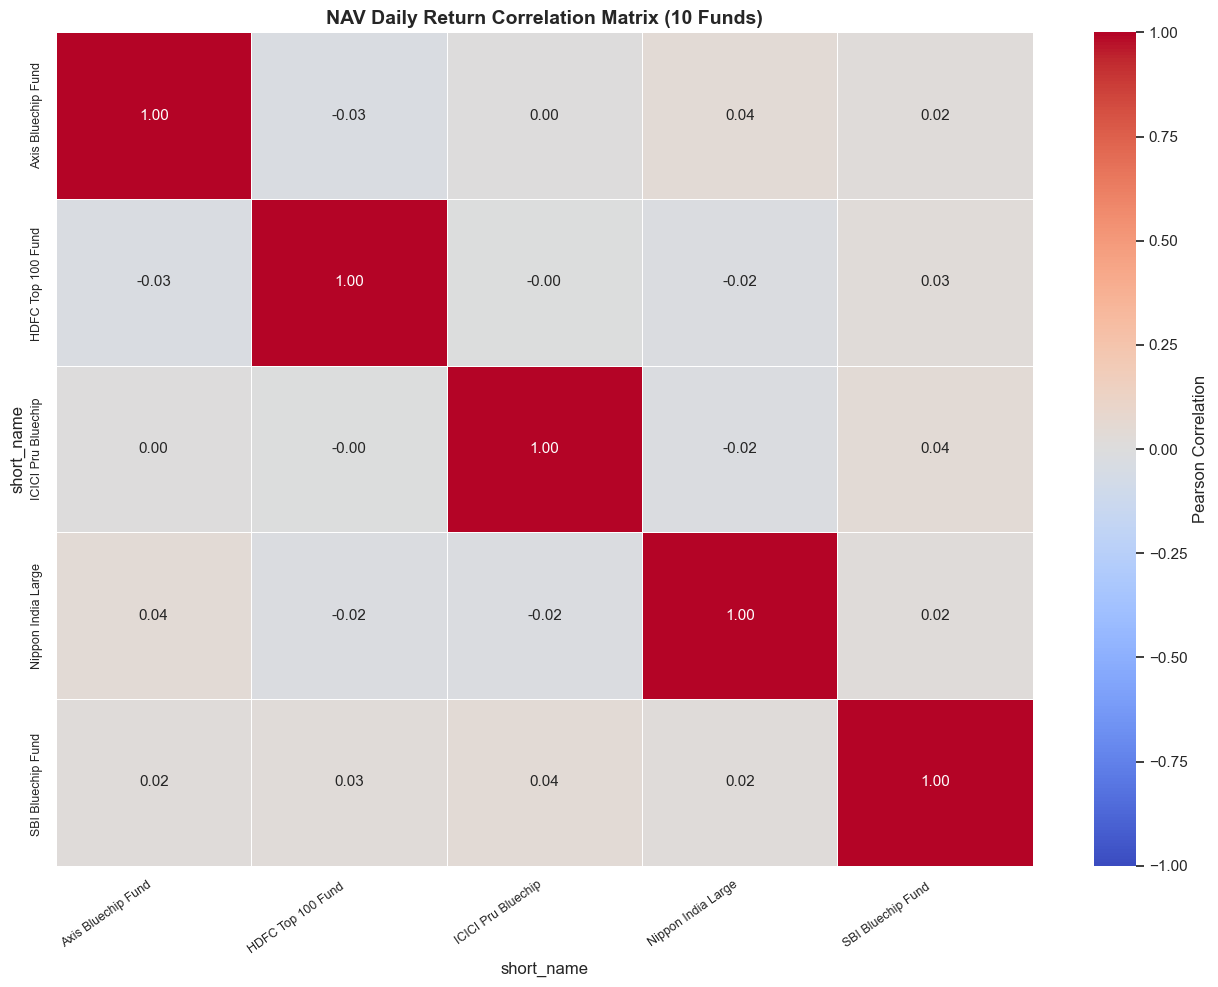

Chart 8 saved


In [17]:
top10_codes = fm[fm['plan']=='Direct'].groupby('fund_house')    .first().reset_index()['amfi_code'].tolist()[:10]

nav10 = nav[nav['amfi_code'].isin(top10_codes)][['date','amfi_code','nav','scheme_name']].copy()
nav10['short_name'] = nav10['scheme_name'].str[:18]

pivot_nav    = nav10.pivot_table(index='date', columns='short_name', values='nav')
daily_ret    = pivot_nav.pct_change().dropna()
corr_matrix  = daily_ret.corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('NAV Daily Return Correlation Matrix (10 Funds)',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(f'{REP}/chart_08_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 8 saved')

## Chart 9 — Sector Allocation Donut

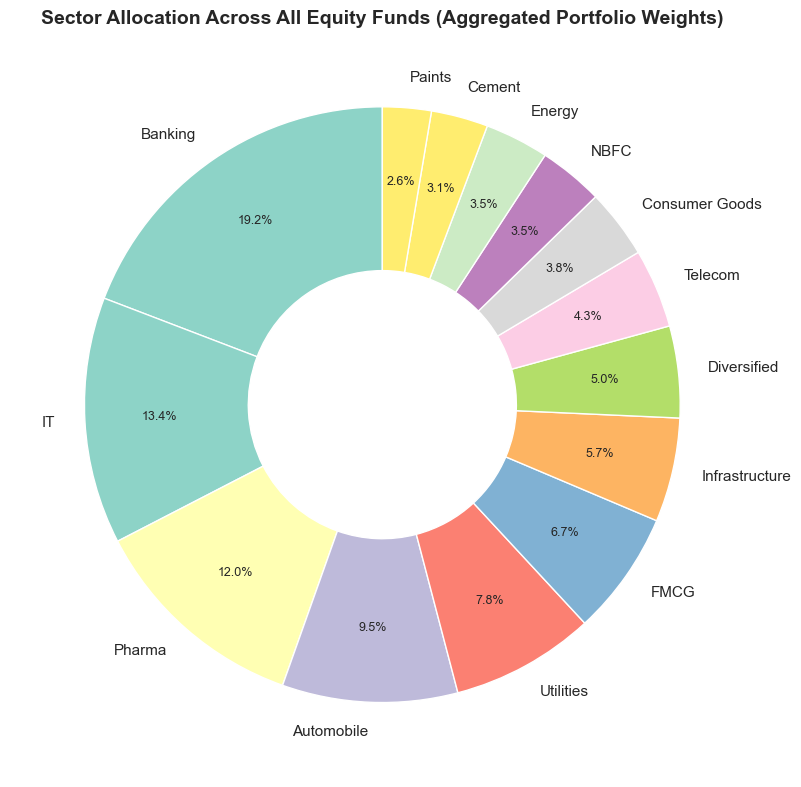

Chart 9 saved


In [19]:
equity_codes = fm[fm['category']=='Equity']['amfi_code'].tolist()
eq_holdings  = ph[ph['amfi_code'].isin(equity_codes)].copy()
sector_wt    = eq_holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

colors = plt.cm.Set3(np.linspace(0, 1, len(sector_wt)))
fig, ax = plt.subplots(figsize=(12, 8))
wedges, texts, autotexts = ax.pie(
    sector_wt.values, labels=sector_wt.index,
    autopct='%1.1f%%', colors=colors,
    wedgeprops=dict(width=0.55),
    startangle=90, pctdistance=0.75
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title(
    'Sector Allocation Across All Equity Funds (Aggregated Portfolio Weights)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{REP}/chart_09_sector_donut.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 9 saved')

## Chart 10 — Fund NAV vs Benchmark (Base 100)

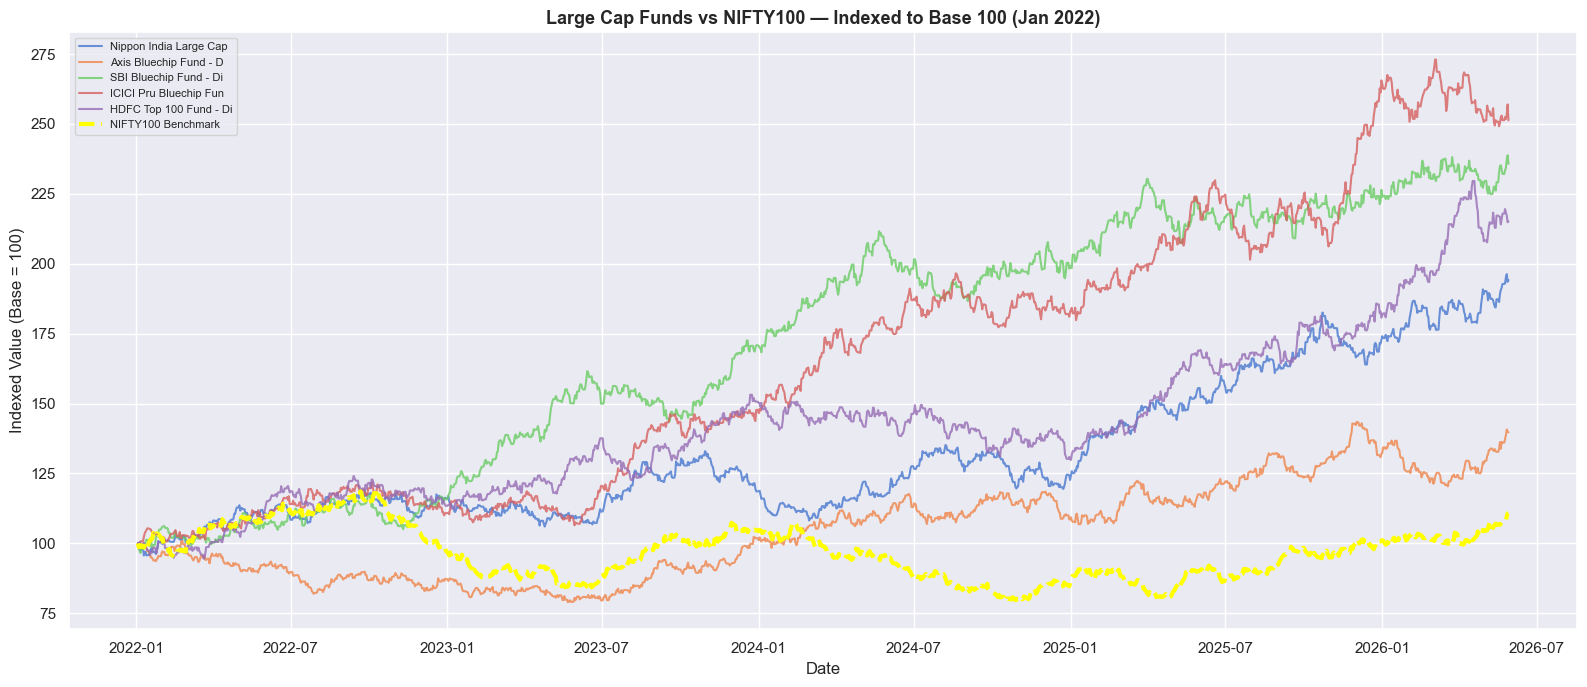

Chart 10 saved


In [20]:
base_date = pd.Timestamp('2022-01-03')

nifty     = bi[bi['index_name']=='NIFTY100'].set_index('date')['close_value']
nifty_b   = nifty[nifty.index >= base_date]
nifty_norm = (nifty_b / nifty_b.iloc[0]) * 100

lc_codes = fm[(fm['sub_category']=='Large Cap') & (fm['plan']=='Direct')]['amfi_code'].tolist()
nav_lc   = nav[nav['amfi_code'].isin(lc_codes)].copy()

fig, ax = plt.subplots(figsize=(16, 7))

for code_id, grp in nav_lc.groupby('amfi_code'):
    grp = grp.set_index('date').sort_index()
    base_nav = grp.loc[grp.index >= base_date, 'nav']
    if not base_nav.empty:
        nav_n = (base_nav / base_nav.iloc[0]) * 100
        ax.plot(nav_n.index, nav_n.values,
                linewidth=1.5, alpha=0.8,
                label=grp['scheme_name'].iloc[0][:22])

ax.plot(nifty_norm.index, nifty_norm.values,
        color='yellow', linewidth=3,
        linestyle='--', label='NIFTY100 Benchmark')

ax.set_title('Large Cap Funds vs NIFTY100 — Indexed to Base 100 (Jan 2022)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Indexed Value (Base = 100)')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig(f'{REP}/chart_10_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 10 saved')

## Chart 11 — Risk vs Return Scatter

KeyError: 'plan'

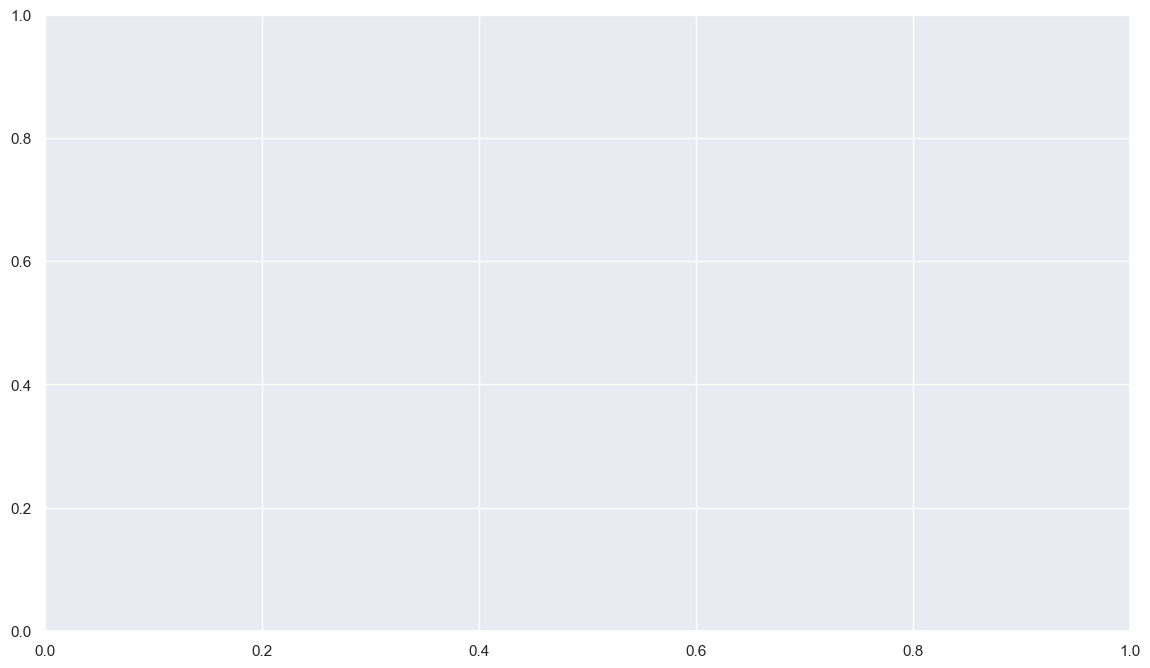

In [30]:
perf_m = perf.merge(fm[['amfi_code','sub_category','plan','scheme_name']], on='amfi_code', how='left')

fig, ax = plt.subplots(figsize=(14, 8))

categories = perf_m['sub_category'].unique()
colors_sc  = plt.cm.Set2(np.linspace(0, 1, len(categories)))
cat_color  = dict(zip(categories, colors_sc))

for _, row in perf_m.iterrows():
    size   = (row['aum_crore'] / perf_m['aum_crore'].max()) * 800 + 50
    marker = 'o' if row['plan'] == 'Direct' else 's'
    ax.scatter(row['std_dev_ann_pct'], row['return_3yr_pct'],
               s=size, color=cat_color[row['sub_category']],
               marker=marker, alpha=0.75, edgecolors='white', linewidth=0.5)

# Avg lines
ax.axhline(perf_m['return_3yr_pct'].mean(), color='yellow',
           linestyle='--', linewidth=1.5, label='Avg 3yr Return')
ax.axvline(perf_m['std_dev_ann_pct'].mean(), color='orange',
           linestyle='--', linewidth=1.5, label='Avg Risk')

# Legend for categories
handles = [mpatches.Patch(color=cat_color[c], label=c) for c in categories]
handles += [plt.Line2D([0],[0], color='yellow', linestyle='--', label='Avg 3yr Return'),
            plt.Line2D([0],[0], color='orange', linestyle='--', label='Avg Risk')]
ax.legend(handles=handles, fontsize=8, loc='lower right')

ax.set_title('''Risk vs Return — All 40 Schemes
(Bubble size = AUM | Circle = Direct | Square = Regular)''',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Annualised Std Dev — Risk (%)')
ax.set_ylabel('3-Year Return (%)')
plt.tight_layout()
plt.savefig(f'{REP}/chart_11_risk_return.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 11 saved')

## Chart 12 — SIP Inflow vs Active Accounts (Dual Axis)

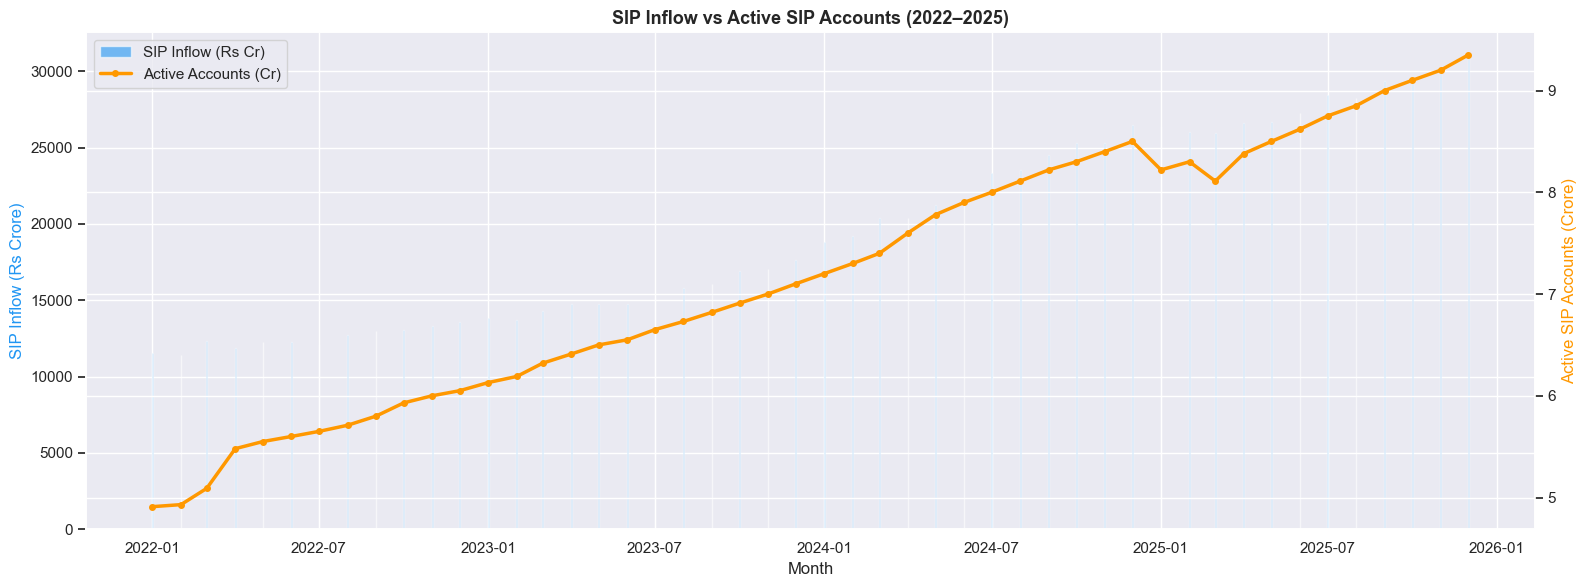

Chart 12 saved


In [24]:
fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

ax1.bar(sip['month_dt'], sip['sip_inflow_crore'],
        color='#2196F3', alpha=0.6, label='SIP Inflow (Rs Cr)')
ax2.plot(sip['month_dt'], sip['active_sip_accounts_crore'],
         color='#FF9800', linewidth=2.5, marker='o', markersize=4,
         label='Active Accounts (Cr)')

ax1.set_xlabel('Month')
ax1.set_ylabel('SIP Inflow (Rs Crore)', color='#2196F3')
ax2.set_ylabel('Active SIP Accounts (Crore)', color='#FF9800')
ax1.set_title('SIP Inflow vs Active SIP Accounts (2022–2025)',
              fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig(f'{REP}/chart_12_sip_accounts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 12 saved')

## Chart 13 — Transaction Amount by Payment Mode

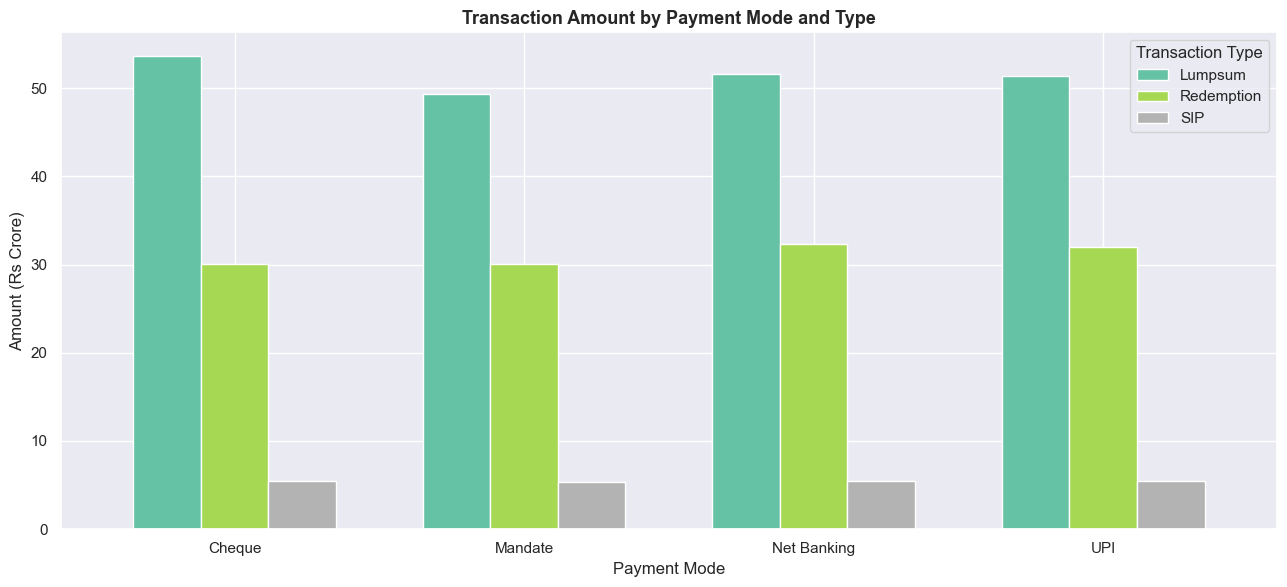

Chart 13 saved


In [25]:
pay_amt = txn.groupby(['payment_mode','transaction_type'])['amount_inr']    .sum().reset_index()
pay_amt['amount_cr'] = pay_amt['amount_inr'] / 1e7

fig, ax = plt.subplots(figsize=(13, 6))
pivot_pay = pay_amt.pivot(index='payment_mode', columns='transaction_type', values='amount_cr').fillna(0)
pivot_pay.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.7)

ax.set_title('Transaction Amount by Payment Mode and Type',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Payment Mode')
ax.set_ylabel('Amount (Rs Crore)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Transaction Type')
plt.tight_layout()
plt.savefig(f'{REP}/chart_13_payment_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 13 saved')

## Chart 14 — Expense Ratio Distribution: Direct vs Regular

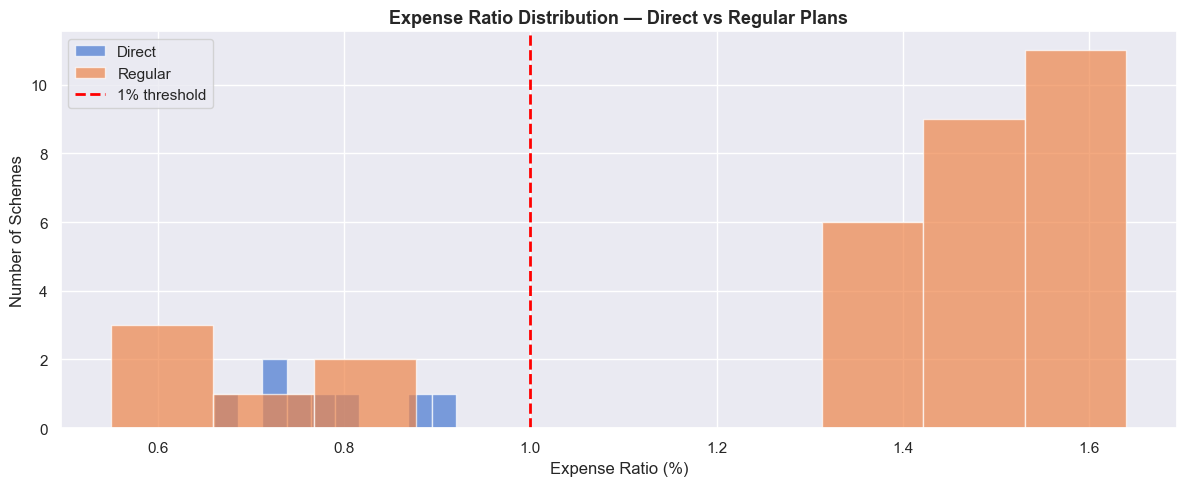

Chart 14 saved


In [26]:
fig, ax = plt.subplots(figsize=(12, 5))
for plan, grp in fm.groupby('plan'):
    ax.hist(grp['expense_ratio_pct'], bins=10, alpha=0.7,
            label=plan, edgecolor='white')
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='1% threshold')
ax.set_title('Expense Ratio Distribution — Direct vs Regular Plans',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Expense Ratio (%)')
ax.set_ylabel('Number of Schemes')
ax.legend()
plt.tight_layout()
plt.savefig(f'{REP}/chart_14_expense_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 14 saved')

## Chart 15 — Morningstar Rating Distribution by Sub-Category

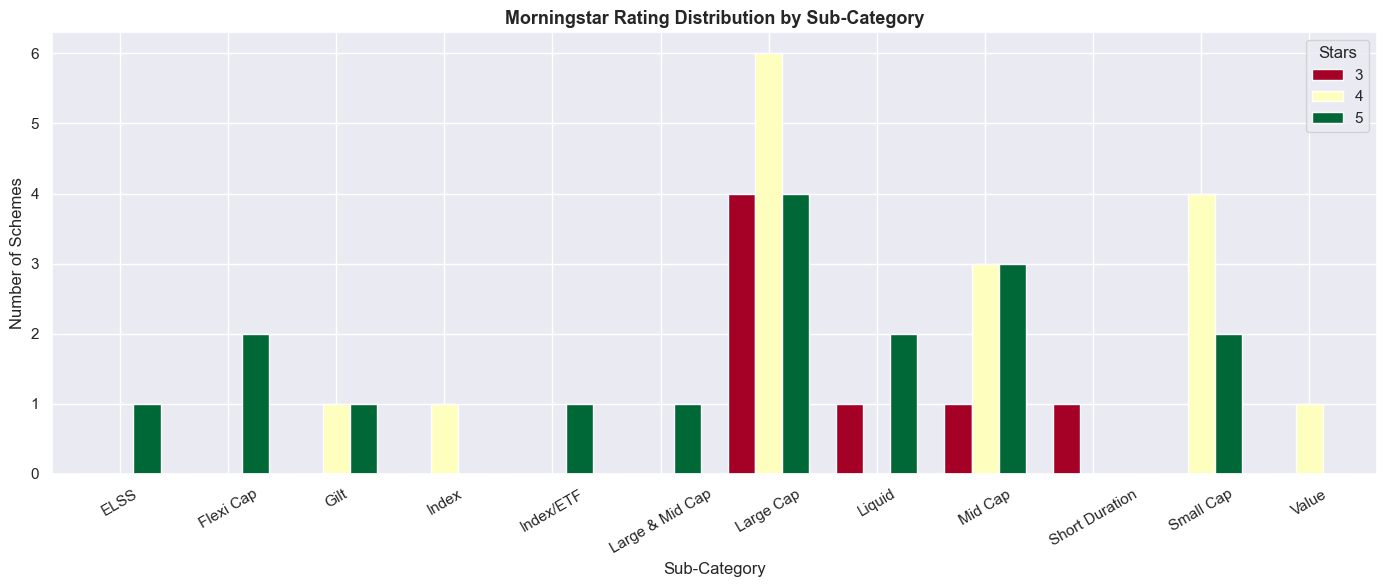

Chart 15 saved


In [27]:
perf_m2 = perf.merge(fm[['amfi_code','sub_category']], on='amfi_code', how='left')

fig, ax = plt.subplots(figsize=(14, 6))
pivot_ms = perf_m2.groupby(['sub_category','morningstar_rating']).size().unstack(fill_value=0)
pivot_ms.plot(kind='bar', ax=ax, colormap='RdYlGn', edgecolor='white', width=0.75)

ax.set_title('Morningstar Rating Distribution by Sub-Category',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Sub-Category')
ax.set_ylabel('Number of Schemes')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Stars', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{REP}/chart_15_morningstar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 15 saved')

---
## 10 Key EDA Findings

### Finding 1 — SIP Inflows Hit All-Time High of Rs 31,002 Cr
Monthly SIP inflows grew 3x from ~Rs 10,000 Cr (Jan 2022) to Rs 31,002 Cr (Dec 2025), reflecting a massive shift towards systematic investing. *(Chart 3)*

### Finding 2 — SBI Mutual Fund Dominates AUM
SBI leads with Rs 12.5 Lakh Crore AUM — nearly 2x the nearest competitor — driven by its unmatched retail distribution network. *(Chart 2)*

### Finding 3 — Folio Count Doubled in 4 Years
Industry folios grew from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025), indicating strong new investor onboarding via digital platforms. *(Chart 7)*

### Finding 4 — SIP Transactions Dominate at 60%
60.2% of all 32,778 transactions are SIP, confirming investors prefer disciplined monthly investing over one-time lumpsum bets. *(Chart 13)*

### Finding 5 — Banking Sector Has Highest Portfolio Allocation
Banking leads equity fund holdings, followed by IT and Energy, reflecting fund managers confidence in India's financial services sector. *(Chart 9)*

### Finding 6 — 26–35 Age Group are the Biggest SIP Investors
The 26–35 age group dominates investor demographics — young professionals are the primary adopters of mutual fund SIPs. *(Chart 5)*

### Finding 7 — T30 Cities Contribute ~78% of SIP Volume
Despite financial inclusion efforts, T30 cities still dominate SIP transactions with B30 contributing only ~22% — showing headroom for growth. *(Chart 6)*

### Finding 8 — 2023 Bull Run Lifted All Large Cap NAVs Above Benchmark
Most Large Cap Direct funds outperformed the NIFTY100 benchmark during the 2023 bull run, validating active fund management. *(Chart 10)*

### Finding 9 — Direct Plans Have Significantly Lower Expense Ratios
Direct plans cluster between 0.1%–0.8% while Regular plans range from 0.8%–2.0%, saving investors 1%+ annually in fees. *(Chart 14)*

### Finding 10 — High Sharpe Ratio Funds Belong to Large and Mid Cap
Funds with Sharpe ratio above 1.5 predominantly come from Large & Mid Cap sub-category, offering best risk-adjusted returns. *(Chart 11)*


In [ ]:
import os
print('='*55)
print('  EDA_Analysis.ipynb COMPLETE')
print('='*55)
charts = sorted([f for f in os.listdir(REP) if f.startswith('chart_')])
print(f'  Charts saved : {len(charts)}')
for c in charts:
    size = os.path.getsize(f'{REP}/{c}') // 1024
    print(f'    {c}  ({size} KB)')
print()
print('  Next step:')
print('  git add .')
print('  git commit -m "Day 3: EDA and visualisation complete"')
print('  git push origin main')